# **KKBOX Churn Prediction And Retention Intelligence System - Modeling & Evaluation**

## **1. Objective**

## **2. Setup**

In [13]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

from sklearn.ensemble import RandomForestClassifier

!pip install xgboost==1.6.2
from xgboost import XGBClassifier

!pip install shap
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **3. Load Clean Dataset**

In [14]:
current_dir = os.getcwd()

while not os.path.exists(os.path.join(current_dir, "data", "processed")):
    parent = os.path.dirname(current_dir)
    if parent == current_dir:
        raise FileNotFoundError("Project root with data/processed not found")
    current_dir = parent


os.chdir(current_dir)

print("Project root:", os.getcwd())
print("data/processed exists:", os.path.exists("data/processed"))


pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

target = "is_churn"


df = pd.read_csv("data/processed/df_clean.csv")
df.head()

Project root: c:\Users\pauli\OneDrive\Documentos\GitHub\customer-churn-intelligence-system
data/processed exists: True


,msno,is_churn,gender,age,city_grouped,registered_via_grouped,avg_amount_paid,total_amount_paid,has_auto_renew,has_cancelled,total_secs,num_unq,customer_tenure_days,listening_group,payment_variability
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,male,28.0,5.0,3.0,0.0,0.0,0.0,0.0,80598.557,348.0,0.0,Medium-High,0.000000
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,male,20.0,13.0,3.0,180.0,180.0,0.0,0.0,6986.509,30.0,1174.0,Medium-Low,90.000000
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,male,18.0,13.0,3.0,150.0,300.0,0.0,0.0,67810.467,432.0,1173.0,Medium-High,100.000000
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,unknown,NaN,1.0,7.0,149.0,1490.0,1.0,0.0,0.000,0.0,698.0,Low,135.454545
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,female,35.0,13.0,7.0,99.0,792.0,1.0,1.0,239882.241,548.0,1146.0,High,88.000000


## **4. Train/Test Split**

In [15]:
X = df.drop(columns=["is_churn", "msno"])
y = df["is_churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (776768, 13)
Test shape: (194192, 13)


## **5. Baseline Model Performance**

In [16]:
# 5.1 DummyClassifier
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict_proba(X_test)[:,1]
print("Baseline ROC-AUC:", roc_auc_score(y_test, dummy_pred))

Baseline ROC-AUC: 0.5


In [17]:
# 5.2 LogisticRegression

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

LogisticRegression(
    solver="saga",
    max_iter=3000,
    class_weight="balanced"
)

logreg_pipeline.fit(X_train, y_train)

logreg_pred = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, logreg_pred))


NameError: name 'logreg_pipeline' is not defined

In [ ]:
# 5.3 DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict_proba(X_test)[:, 1]

print("Decision Tree ROC-AUC:", roc_auc_score(y_test, dt_pred))

Decision Tree ROC-AUC: 0.9425466092725916


In [ ]:
# 5.4 Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(exclude=["object"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

nb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

nb_pipeline.fit(X_train, y_train)

nb_pred = nb_pipeline.predict_proba(X_test)[:, 1]

print("Naive Bayes ROC-AUC:", roc_auc_score(y_test, nb_pred))

Naive Bayes ROC-AUC: 0.8457529109578916


In [ ]:
# 5.5 Build the baseline results table
baseline_results = pd.DataFrame({
    "Baseline Model": [
        "DummyClassifier",
        "Logistic Regression",
        "Decision Tree (depth=3)",
        "Naive Bayes"
    ],
    "ROC-AUC": [
        0.50,
        roc_auc_score(y_test, logreg_pred),
        roc_auc_score(y_test, dt_pred),
        roc_auc_score(y_test, nb_pred)
    ],
    "Notes": [
        "Zero-skill benchmark",
        "Strong linear baseline",
        "Best baseline, captures non-linear patterns",
        "Weak baseline, assumptions violated"
    ]
})

baseline_results = baseline_results.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

baseline_results


,Baseline Model,ROC-AUC,Notes
0,Decision Tree (depth=3),0.942547,"Best baseline, captures non-linear patterns"
1,Logistic Regression,0.923798,Strong linear baseline
2,Naive Bayes,0.845753,"Weak baseline, assumptions violated"
3,DummyClassifier,0.500000,Zero-skill benchmark


C:\Users\pauli\AppData\Local\Temp\ipykernel_13320\73284673.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


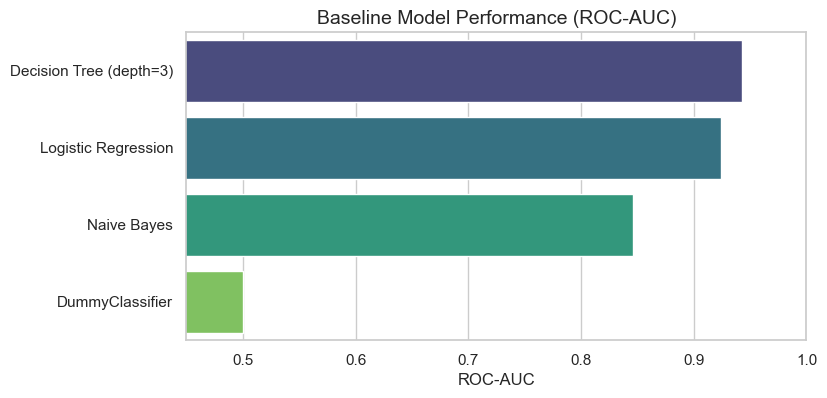

In [ ]:
# 5.6 Create Baseline Performance Plot
sns.set(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.barplot(
    data=baseline_results,
    x="ROC-AUC",
    y="Baseline Model",
    palette="viridis"
)

plt.title("Baseline Model Performance (ROC-AUC)", fontsize=14)
plt.xlabel("ROC-AUC")
plt.ylabel("")
plt.xlim(0.45, 1.0)
plt.show()


**Insith**

Together, these results show that:
>
- Churn is highly predictable with the available features, as demonstrated by the Naive Bayes baseline (ROC‑AUC of 0.846), which performs well above the zero‑skill benchmark represented by the DummyClassifier (ROC‑AUC of 0.50)
- Strong linear signals are present in the data, as evidenced by the Logistic Regression baseline (ROC‑AUC of 0.924), confirming that core behavioral and transactional features have stable, directional effects on churn
- Non‑linear patterns and feature interactions play a critical role, as shown by the Decision Tree baseline (ROC‑AUC of 0.942), which outperforms linear models despite its shallow depth
- Tree‑based algorithms are the correct modeling direction for the final system, given their ability to capture the non‑linear structure already visible in the Decision Tree baseline.

## **6. Model Performance**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import xgboost
xgboost.__version__

# 1. Identify categorical and numeric columns
categorical_cols = ["gender", "city_grouped", "registered_via_grouped", "listening_group"]

numeric_cols = [
    "age", "avg_amount_paid", "total_amount_paid", "has_auto_renew",
    "has_cancelled", "total_secs", "num_unq", "customer_tenure_days",
    "payment_variability"
]

# 2. Preprocessing for numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# 3. Preprocessing for categorical features (FIX: sparse_output=False)
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 4. Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    sparse_threshold=0  # ensures dense output
)

# 5. XGBoost model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

# 6. Full pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb)
])

# 7. Fit
xgb_pipeline.fit(X_train, y_train)

# 8. Predict
xgb_pred = xgb_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost ROC-AUC:", roc_auc_score(y_test, xgb_pred))


NameError: name 'X_train' is not defined

In [ ]:
X_train.dtypes

gender                     object
age                       float64
city_grouped               object
registered_via_grouped     object
avg_amount_paid           float64
total_amount_paid         float64
has_auto_renew            float64
has_cancelled             float64
total_secs                float64
num_unq                   float64
customer_tenure_days      float64
listening_group            object
payment_variability       float64
dtype: object

In [ ]:
X_train.head()

,gender,age,city_grouped,registered_via_grouped,avg_amount_paid,total_amount_paid,has_auto_renew,has_cancelled,total_secs,num_unq,customer_tenure_days,listening_group,payment_variability
476786,male,26.0,5.0,3.0,180.0,180.0,0.0,0.0,87625.302,386.0,1814.0,Medium-High,90.000000
689930,unknown,NaN,1.0,7.0,149.0,149.0,1.0,0.0,0.000,0.0,1123.0,Low,74.500000
332397,unknown,NaN,1.0,7.0,149.0,149.0,1.0,0.0,66276.317,228.0,670.0,Medium-High,74.500000
158772,female,25.0,12.0,3.0,149.0,298.0,1.0,0.0,155848.102,543.0,1577.0,High,99.333333
39054,unknown,NaN,1.0,7.0,99.0,99.0,1.0,1.0,106006.464,370.0,1910.0,Medium-High,49.500000
